# Basic LSTM Demonstration

This notebook demonstrates the ability of a LSTM model to analyze time series data and make predictions on a trivial dataset.  It serves several purposes for the author:

 1. Verify understanding of [LSTM parameters in PyTorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
 2. Verify understanding of tensor shape requirements for LSTM model input, hidden state, and output in PyTorch
 3. Explore the operation of PyTorch Datasets and DataLoaders with unbatched and batched input, particularly the resulting tensors produced for LSTM model input.  Confirm tensor shapes are aligned with LSTM model input requirements.

Author: Pete King

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

import data_prep as dp
import models

WINDOW_SIZE = 10
BATCH_SIZE = 5

## I. Prepare Data

The ultimate goal with this notebook is to improve the author's understanding of how Datasets, DataLoaders, and the LSTM model behave in PyTorch.  Getting it right for this toy dataset will reinforce basic concepts before attempting a more complicated (possibly multivariate) deep learning model based on the LSTM architecture.

### Create Toy Dataset

Here we generate a sine wave to serve as a simplistic dataset for training the LSTM.  We expect that the LSTM will only be able to learn to predict the next value in the series if we have set up the input features, datasets, and dataloaders correctly.


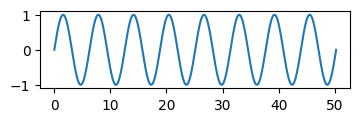

In [10]:
# Toy Data: A simple cosine wave
t = np.linspace(0, torch.pi * 16, 10**3).astype(np.float32)  # required for LSTM
x = np.sin(t).astype(np.float32)

# Plot data
fig = plt.figure(figsize=(4, 1))
ax = fig.subplots()
ax.plot(t, x)

### Generate input feature vectors and labels

We operate on the idea that the sine wave represents a simple repeating pattern that an LSTM can learn.  We use a backward-looking rolling window of length *L* to generate feature vectors.  Each feature vector is a sequence of values of the sine function at successive timestamps.  Thus each feature vector encodes a segment of sine wave.  This encoding is only useful if there are patterns in the sine wave that repeat over time (and thus can be used to predict a future value).

Consider each feature vector (x_(t-L)) as a sample of the data taken at time t, from time (t - L) to time (t - 1).

In this example, we try to predict the value (y) of the sine wave at time t (i.e., y = sin(t)).  Without batching samples, our input to the LSTM will be a matrix (X) where each row is a feature vector of length L, and there are (n - L) feature vectors (rows) total, where n is the total number of data points in the series.

In [11]:
# The dataset uses a backward-looking rolling window to generate feature 
# vectors from timestamps [t - window_size, t), i.e., the data at time t is 
# not included in the feature vector.

dataset = dp.UnivariateTimeSeriesDataset(x, window_size=WINDOW_SIZE)
x_0, y_0 = dataset[0][0], dataset[0][1]
print('First sample in the dataset:')
print(x_0)
print(f'Shape of first sample: {x_0.shape}')
print(f'First label in the dataset: {y_0}')
print(f'Shape of first label: {y_0.shape}')

First sample in the dataset:
tensor([[0.0000],
        [0.0503],
        [0.1005],
        [0.1504],
        [0.1999],
        [0.2489],
        [0.2973],
        [0.3450],
        [0.3917],
        [0.4375]])
Shape of first sample: torch.Size([10, 1])
First label in the dataset: tensor([0.4822])
Shape of first label: torch.Size([1])


**We verify that the label (y = sin(t)) is not included in the input feature vector (x).**

In [12]:
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
# Verify shape of input tensors
input_0, label_0 = next(iter(dataloader))
print(f'Shape of input tensor: {input_0.shape}')
print(f'Shape of label: {label_0.shape}')

Shape of input tensor: torch.Size([5, 10, 1])
Shape of label: torch.Size([5, 1])


## II. Create and Train LSTM Model

In [13]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [14]:
# Define LSTM parameters
input_size = 1  # Number of features in data (x), in this case scalar values
hidden_size = 16  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # batch size
L = 10  # sequence length (number of time steps)
D = int(bidirectional + 1)  # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size  # scalar input
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y) for multivariate LSTM
label_size = 1  # Number of features in labels, in this case scalar values

In [15]:
model = models.FinancialLSTM(
    input_size,
    label_size,
    hidden_size,
    num_layers,
    batch_first,
    bidirectional,
    proj_size,
)

In [16]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [17]:
# Train and evaluate model
epochs = 10
all_preds = []
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(dataloader, model, loss_fn, optimizer)
    loss_val, preds = models.evaluate_model(dataloader, model, loss_fn)
    all_preds.append(preds)
    if epochs <= 20:
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')
    else:
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}')
            print(f'Training loss:   {loss_trn}')
            print(f'Validation loss: {loss_val}')

Training model over 10 epochs...
Epoch 1
Training loss:   0.4698750376701355
Validation loss: 0.4648841321468353
Epoch 2
Training loss:   0.3165711760520935
Validation loss: 0.31006574630737305
Epoch 3
Training loss:   0.1203591600060463
Validation loss: 0.11166586726903915
Epoch 4
Training loss:   0.011786501854658127
Validation loss: 0.020619630813598633
Epoch 5
Training loss:   0.02599741891026497
Validation loss: 0.026730384677648544
Epoch 6
Training loss:   0.016940316185355186
Validation loss: 0.019194360822439194
Epoch 7
Training loss:   0.047526560723781586
Validation loss: 0.052557192742824554
Epoch 8
Training loss:   0.03527545556426048
Validation loss: 0.03528352454304695
Epoch 9
Training loss:   0.0038339283782988787
Validation loss: 0.006786467041820288
Epoch 10
Training loss:   0.05774455517530441
Validation loss: 0.05640394240617752


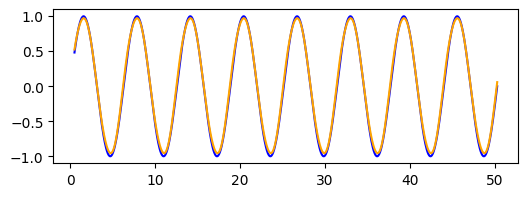

In [19]:
fig = plt.figure(figsize=(6, 2))
ax = fig.subplots()
ax.plot(t[10:], x[10:], color='blue')
ax.plot(t[10:], preds, color='orange')